In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
#from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Model
# import lightgbm as lgb
# from lightgbm import LGBMClassifier

# Evaluasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import randint, uniform

# Imblearn pipeline akan menangani oversampling DENGAN BENAR
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

# ColumnTransformer untuk menerapkan preprocessing yang berbeda ke kolom berbeda
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

#Import Data

In [5]:
#Clone repository dari github untuk mengakses dataset yang telah diunggah di github sebelumnya
!git clone https://github.com/Andishafira/Dicoding.git

fatal: destination path 'Dicoding' already exists and is not an empty directory.


In [6]:
#Baca datset
import pandas as pd

df = pd.read_csv("/content/Dicoding/Belajar_Penerapan_Data_Science/Tugas_2_Menyelesaikan_Permasalahan_Institusi_Pendidikan/data.csv", sep=";")
df.head(100)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,15,1,9119,1,1,130.0,26,38,3,...,0,5,11,3,13.250000,0,13.9,-0.3,0.79,Enrolled
96,1,1,5,9773,1,1,135.0,1,37,1,...,0,6,6,6,13.333333,0,8.9,1.4,3.51,Graduate
97,1,1,5,9500,1,1,132.0,1,37,37,...,0,8,9,8,14.477778,0,12.4,0.5,1.79,Graduate
98,1,1,1,9085,1,1,135.0,1,1,2,...,0,5,7,5,13.800000,0,12.7,3.7,-1.70,Enrolled


# Data Understanding

Melakukan pengecekan apakah dataset ada data kosong juga tipe data dalam tiap kolomnya

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application_mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application_order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime_evening_attendance,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous_qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous_qualification_grade,4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mothers_qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Fathers_qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


In [9]:
#Melakukan decoding untuk mengubah nilai-nilai kategoris yang direpresentasikan dalam bentuk numerik menjadi label string yang lebih deskriptif dan mudah dipahami
def decode_dataframe(df):
    df = df.copy()
    marital_status_mapping = {
        1: 'single',
        2: 'married',
        3: 'widower',
        4: 'divorced',
        5: 'facto union',
        6: 'legally separated'
    }
    df['Marital_status']=df['Marital_status'].map(marital_status_mapping)

    application_mode_mapping = {
        1: '1st phase - general contingent',
        2: 'Ordinance No. 612/93',
        5: '1st phase - special contingent (Azores Island)',
        7: 'Holders of other higher courses',
        10: 'Ordinance No. 854-B/99',
        15: 'International student (bachelor)',
        16: '1st phase - special contingent (Madeira Island)',
        17: '2nd phase - general contingent',
        18: '3rd phase - general contingent',
        26: 'Ordinance No. 533-A/99, item b2) (Different Plan)',
        27: 'Ordinance No. 533-A/99, item b3 (Other Institution)',
        39: 'Over 23 years old',
        42: 'Transfer',
        43: 'Change of course',
        44: 'Technological specialization diploma holders',
        51: 'Change of institution/course',
        53: 'Short cycle diploma holders',
        57: 'Change of institution/course (International)'
    }
    df['Application_mode']=df['Application_mode'].map(application_mode_mapping)

    course_mapping = {
        33: 'Biofuel Production Technologies',
        171: 'Animation and Multimedia Design',
        8014: 'Social Service (evening attendance)',
        9003: 'Agronomy',
        9070: 'Communication Design',
        9085: 'Veterinary Nursing',
        9119: 'Informatics Engineering',
        9130: 'Equinculture',
        9147: 'Management',
        9238: 'Social Service',
        9254: 'Tourism',
        9500: 'Nursing',
        9556: 'Oral Hygiene',
        9670: 'Advertising and Marketing Management',
        9773: 'Journalism and Communication',
        9853: 'Basic Education',
        9991: 'Management (evening attendance)'
    }
    df['Course']=df['Course'].map(course_mapping)

    daytime_evening_mapping = {
        1: 'daytime',
        0: 'evening'
    }
    df['Daytime_evening_attendance']=df['Daytime_evening_attendance'].map(daytime_evening_mapping)

    previous_qualification_mapping = {
        1: 'Secondary education',
        2: "Higher education - bachelor's degree",
        3: 'Higher education - degree',
        4: 'Higher education - master\'s',
        5: 'Higher education - doctorate',
        6: 'Frequency of higher education',
        9: '12th year of schooling - not completed',
        10: '11th year of schooling - not completed',
        12: 'Other - 11th year of schooling',
        14: '10th year of schooling',
        15: '10th year of schooling - not completed',
        19: 'Basic education 3rd cycle (9th/10th/11th year) or equiv.',
        38: 'Basic education 2nd cycle (6th/7th/8th year) or equiv.',
        39: 'Technological specialization course',
        40: 'Higher education - degree (1st cycle)',
        42: 'Professional higher technical course',
        43: 'Higher education - master (2nd cycle)'
    }
    df['Previous_qualification']=df['Previous_qualification'].map(previous_qualification_mapping)

    nationality_mapping = {
        1: 'Portuguese',
        2: 'German',
        6: 'Spanish',
        11: 'Italian',
        13: 'Dutch',
        14: 'English',
        17: 'Lithuanian',
        21: 'Angolan',
        22: 'Cape Verdean',
        24: 'Guinean',
        25: 'Mozambican',
        26: 'Santomean',
        32: 'Turkish',
        41: 'Brazilian',
        62: 'Romanian',
        100: 'Moldova (Republic of)',
        101: 'Mexican',
        103: 'Ukrainian',
        105: 'Russian',
        108: 'Cuban',
        109: 'Colombian'
    }
    df['Nacionality']=df['Nacionality'].map(nationality_mapping)

    qualification_mapping = {
        1: 'Secondary Education - 12th Year of Schooling or Eq.',
        2: 'Higher Education - Bachelor\'s Degree',
        3: 'Higher Education - Degree',
        4: 'Higher Education - Master\'s',
        5: 'Higher Education - Doctorate',
        6: 'Frequency of Higher Education',
        9: '12th Year of Schooling - Not Completed',
        10: '11th Year of Schooling - Not Completed',
        11: '7th Year (Old)',
        12: 'Other - 11th Year of Schooling',
        14: '10th Year of Schooling',
        18: 'General Commerce Course',
        19: 'Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.',
        22: 'Technical-Professional Course',
        26: '7th Year of Schooling',
        27: '2nd Cycle of the General High School Course',
        29: '9th Year of Schooling - Not Completed',
        30: '8th Year of Schooling',
        34: 'Unknown',
        35: 'Can\'t Read or Write',
        36: 'Can Read Without Having a 4th Year of Schooling',
        37: 'Basic Education 1st Cycle (4th/5th Year) or Equiv.',
        38: 'Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.',
        39: 'Technological Specialization Course',
        40: 'Higher Education - Degree (1st Cycle)',
        41: 'Specialized Higher Studies Course',
        42: 'Professional Higher Technical Course',
        43: 'Higher Education - Master (2nd Cycle)',
        44: 'Higher Education - Doctorate (3rd Cycle)'
    }
    df['Mothers_qualification']=df['Mothers_qualification'].map(qualification_mapping)
    df['Fathers_qualification']=df['Fathers_qualification'].map(qualification_mapping)

    occupation_mapping = {
        0: 'Student',
        1: 'Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers',
        2: 'Specialists in Intellectual and Scientific Activities',
        3: 'Intermediate Level Technicians and Professions',
        4: 'Administrative staff',
        5: 'Personal Services, Security and Safety Workers and Sellers',
        6: 'Farmers and Skilled Workers in Agriculture, Fisheries and Forestry',
        7: 'Skilled Workers in Industry, Construction and Craftsmen',
        8: 'Installation and Machine Operators and Assembly Workers',
        9: 'Unskilled Workers',
        10: 'Armed Forces Professions',
        90: 'Other Situation',
        99: '(blank)',
        101: 'Armed Forces Officers',
        102: 'Armed Forces Sergeants',
        103: 'Other Armed Forces personnel',
        112: 'Directors of administrative and commercial services',
        114: 'Hotel, catering, trade and other services directors',
        121: 'Specialists in the physical sciences, mathematics, engineering and related techniques',
        122: 'Health professionals',
        123: 'Teachers',
        124: 'Specialists in finance, accounting, administrative organization, public and commercial relations',
        131: 'Intermediate level science and engineering technicians and professions',
        132: 'Technicians and professionals, of intermediate level of health',
        134: 'Intermediate level technicians from legal, social, sports, cultural and similar services',
        135: 'Information and communication technology technicians',
        141: 'Office workers, secretaries in general and data processing operators',
        143: 'Data, accounting, statistical, financial services and registry-related operators',
        144: 'Other administrative support staff',
        151: 'Personal service workers',
        152: 'Sellers',
        153: 'Personal care workers and the like',
        154: 'Protection and security services personnel',
        161: 'Market-oriented farmers and skilled agricultural and animal production workers',
        163: 'Farmers, livestock keepers, fishermen, hunters and gatherers, subsistence',
        171: 'Skilled construction workers and the like, except electricians',
        172: 'Skilled workers in metallurgy, metalworking and similar',
        174: 'Skilled workers in electricity and electronics',
        175: 'Workers in food processing, woodworking, clothing and other industries and crafts',
        181: 'Fixed plant and machine operators',
        182: 'Assembly workers',
        183: 'Vehicle drivers and mobile equipment operators',
        192: 'Unskilled workers in agriculture, animal production, fisheries and forestry',
        193: 'Unskilled workers in extractive industry, construction, manufacturing and transport',
        194: 'Meal preparation assistants',
        195: 'Street vendors (except food) and street service providers'
    }
    df['Mothers_occupation']=df['Mothers_occupation'].map(occupation_mapping)
    df['Fathers_occupation']=df['Fathers_occupation'].map(occupation_mapping)

    yes_no_mapping = {
        1: 'yes',
        0: 'no'
    }
    df['Displaced']=df['Displaced'].map(yes_no_mapping)
    df['Educational_special_needs']=df['Educational_special_needs'].map(yes_no_mapping)
    df['Debtor']=df['Debtor'].map(yes_no_mapping)
    df['Tuition_fees_up_to_date']=df['Tuition_fees_up_to_date'].map(yes_no_mapping)
    df['Scholarship_holder']=df['Scholarship_holder'].map(yes_no_mapping)
    df['International']=df['International'].map(yes_no_mapping)

    gender_mapping = {
        1: 'male',
        0: 'female'
    }
    df['Gender']=df['Gender'].map(gender_mapping)

    return df

Fungsi decode_dataframe ini dirancang untuk melakukan transformasi data pada sebuah DataFrame dari pustaka pandas. Tujuan utamanya adalah untuk mengubah nilai nilai kategoris yang direpresentasikan dalam bentuk numerik menjadi label string yang lebih deskriptif dan mudah dipahami. Proses ini diawali dengan membuat salinan dari DataFrame masukan untuk memastikan bahwa objek data asli tidak termodifikasi. Selanjutnya, fungsi ini secara sistematis memproses beberapa kolom spesifik, seperti status perkawinan, mode aplikasi, kualifikasi sebelumnya, dan data demografis lainnya dengan menerapkan metode .map(). Untuk setiap kolom target, sebuah kamus pemetaan (mapping dictionary) telah didefinisikan, di mana setiap kunci numerik dipasangkan dengan nilai string yang sesuai. Dengan menerapkan pemetaan ini, fungsi tersebut secara efektif menggantikan kode numerik di dalam kolom dengan label tekstualnya, sehingga meningkatkan keterbacaan dan interpretasi data. Setelah semua transformasi yang ditentukan selesai, fungsi ini mengembalikan DataFrame yang telah dimodifikasi dan siap untuk analisis lebih lanjut.

In [10]:
decoded_df=decode_dataframe(df)
decoded_df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,single,2nd phase - general contingent,5,Animation and Multimedia Design,daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,single,International student (bachelor),1,Tourism,daytime,Secondary education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,single,1st phase - general contingent,5,Communication Design,daytime,Secondary education,122.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 1st Cycle (4th/5th Year) or Eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,single,2nd phase - general contingent,2,Journalism and Communication,daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic Education 1st Cycle (4th/5th Year) or Eq...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,married,Over 23 years old,1,Social Service (evening attendance),evening,Secondary education,100.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


ANALISIS VARIABEL TARGET (Status)

[ Distribusi Nilai pada Kolom 'Status' ]
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

[ Persentase Distribusi Kolom 'Status' ]
Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


/tmp/ipython-input-2113545774.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=decoded_df, order=status_counts.index, palette='viridis')


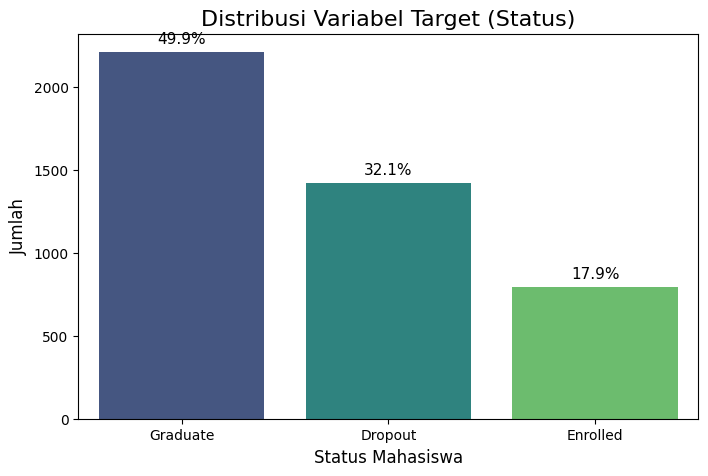

Plot di atas menunjukkan bahwa data kita tidak seimbang (imbalanced).
Jumlah 'Graduate' paling banyak, diikuti 'Dropout', dan 'Enrolled'.


In [11]:
if 'df' in locals():
    print("ANALISIS VARIABEL TARGET (Status)")

    target_col = 'Status'

    # Menghitung jumlah unik dari variabel target
    print(f"\n[ Distribusi Nilai pada Kolom '{target_col}' ]")
    status_counts = decoded_df[target_col].value_counts()
    print(status_counts)

    # Menghitung persentase
    print(f"\n[ Persentase Distribusi Kolom '{target_col}' ]")
    status_percentage = decoded_df[target_col].value_counts(normalize=True) * 100
    print(status_percentage)

    # Visualisasi distribusi variabel target
    plt.figure(figsize=(8, 5))
    sns.countplot(x=target_col, data=decoded_df, order=status_counts.index, palette='viridis')
    plt.title('Distribusi Variabel Target (Status)', fontsize=16)
    plt.xlabel('Status Mahasiswa', fontsize=12)
    plt.ylabel('Jumlah', fontsize=12)

    # Menambahkan label persentase di atas bar
    for i, count in enumerate(status_counts):
        percentage = status_percentage.iloc[i]
        plt.text(i, count + 50, f'{percentage:.1f}%', ha='center', fontsize=11)

    plt.show()
    print("Plot di atas menunjukkan bahwa data kita tidak seimbang (imbalanced).")
    print("Jumlah 'Graduate' paling banyak, diikuti 'Dropout', dan 'Enrolled'.")

Visualisasi ini bertujuan untuk menggambarkan sebaran atau frekuensi dari setiap kategori dalam variabel status mahasiswa.

Dari grafik tersebut, dapat ditarik beberapa kesimpulan utama yaitu:

1. Kategori Dominan: Mahasiswa dengan status "Graduate" (Lulus) merupakan kelompok terbesar, mencakup 49.9% dari total keseluruhan data. Ini ditunjukkan oleh batang tertinggi yang tingginya mencapai lebih dari 2000.

2. Kategori Kedua: Di posisi kedua adalah mahasiswa dengan status "Dropout" (Keluar), yang merepresentasikan 32.1% dari populasi data.

3. Kategori Minoritas: Kategori terkecil adalah mahasiswa yang masih "Enrolled" (Terdaftar/Aktif), yang hanya mencakup 17.9% dari total data.

Secara keseluruhan, grafik ini menunjukkan adanya ketidakseimbangan (imbalance) dalam distribusi kelas pada variabel target. Kategori "Graduate" hampir setengah dari keseluruhan dataset, sementara jumlah mahasiswa yang "Enrolled" jauh lebih sedikit dibandingkan dua kategori lainnya. Informasi ini sangat penting, terutama dalam konteks pemodelan prediktif, karena dapat memengaruhi kinerja model jika tidak ditangani dengan tepat.

ANALISIS FITUR (CONTOH)

[ Analisis Fitur: Age_at_enrollment ]


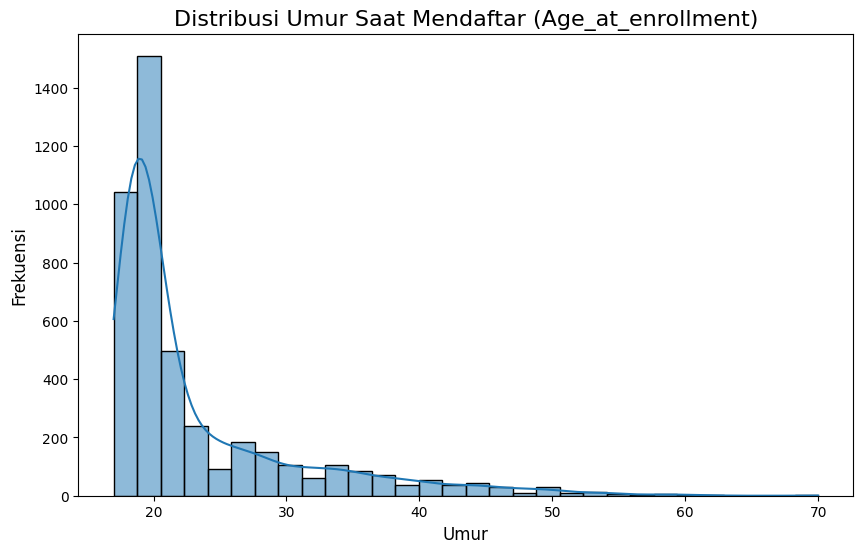

Umur rata-rata: 23.27
Umur median: 20.0

[ Analisis Fitur: Gender ]


/tmp/ipython-input-294799053.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender_label', data=df_plot, palette='pastel')


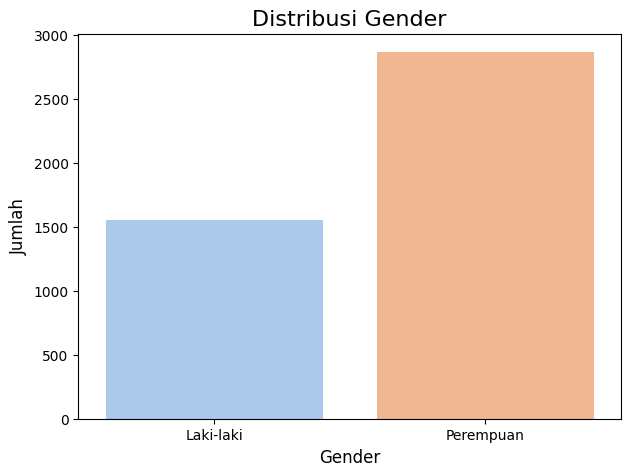

Gender_label
Perempuan    64.82821
Laki-laki    35.17179
Name: proportion, dtype: float64


In [12]:
if 'df' in locals():
    print("ANALISIS FITUR (CONTOH)")

    # --- Contoh 1: Fitur Numerik (Age_at_enrollment) ---
    print("\n[ Analisis Fitur: Age_at_enrollment ]")
    plt.figure(figsize=(10, 6))
    sns.histplot(decoded_df['Age_at_enrollment'], kde=True, bins=30)
    plt.title('Distribusi Umur Saat Mendaftar (Age_at_enrollment)', fontsize=16)
    plt.xlabel('Umur', fontsize=12)
    plt.ylabel('Frekuensi', fontsize=12)
    plt.show()
    print(f"Umur rata-rata: {decoded_df['Age_at_enrollment'].mean():.2f}")
    print(f"Umur median: {decoded_df['Age_at_enrollment'].median()}")

    # Fitur Kategorikal (Gender)
    # Mengganti nilai 0 dan 1 agar lebih mudah dibaca di plot
    df_plot = df.copy()
    df_plot['Gender_label'] = df_plot['Gender'].map({1: 'Laki-laki', 0: 'Perempuan'})

    print("\n[ Analisis Fitur: Gender ]")
    plt.figure(figsize=(7, 5))
    sns.countplot(x='Gender_label', data=df_plot, palette='pastel')
    plt.title('Distribusi Gender', fontsize=16)
    plt.xlabel('Gender', fontsize=12)
    plt.ylabel('Jumlah', fontsize=12)
    plt.show()
    print(df_plot['Gender_label'].value_counts(normalize=True) * 100)


**Grafik Distribusi Umur Saat Mendaftar (Age_at_enrollment)**

* Puncak Distribusi: Puncak tertinggi dari grafik berada pada rentang usia sekitar 18 hingga 20 tahun, dengan frekuensi mencapai hampir 1.500 mahasiswa. Ini menunjukkan bahwa mayoritas mahasiswa mendaftar pada usia muda, yang umumnya merupakan usia lulusan sekolah menengah atas.

* Kemiringan (Skewness): Distribusi data ini sangat miring ke kanan (right-skewed) atau memiliki ekor yang panjang di sisi kanan. Artinya, setelah mencapai puncaknya di usia muda, jumlah mahasiswa yang mendaftar menurun secara signifikan seiring bertambahnya usia. Meskipun demikian, tetap ada sejumlah kecil mahasiswa yang mendaftar di usia yang lebih matang (di atas 30, 40, hingga 60-an), namun jumlahnya tidak signifikan.

* Garis Kurva (KDE Plot): Garis biru yang melengkung secara mulus di atas histogram adalah Kernel Density Estimate (KDE). Garis ini memberikan estimasi yang lebih halus mengenai bentuk distribusi probabilitas dari data umur, dan secara visual mengonfirmasi bahwa distribusinya memang sangat miring ke kanan.

6. ANALISIS BIVARIAT (FITUR vs TARGET)

[ Hubungan: Admission_grade vs Status ]


/tmp/ipython-input-4181862503.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y='Admission_grade', data=df, palette='coolwarm')


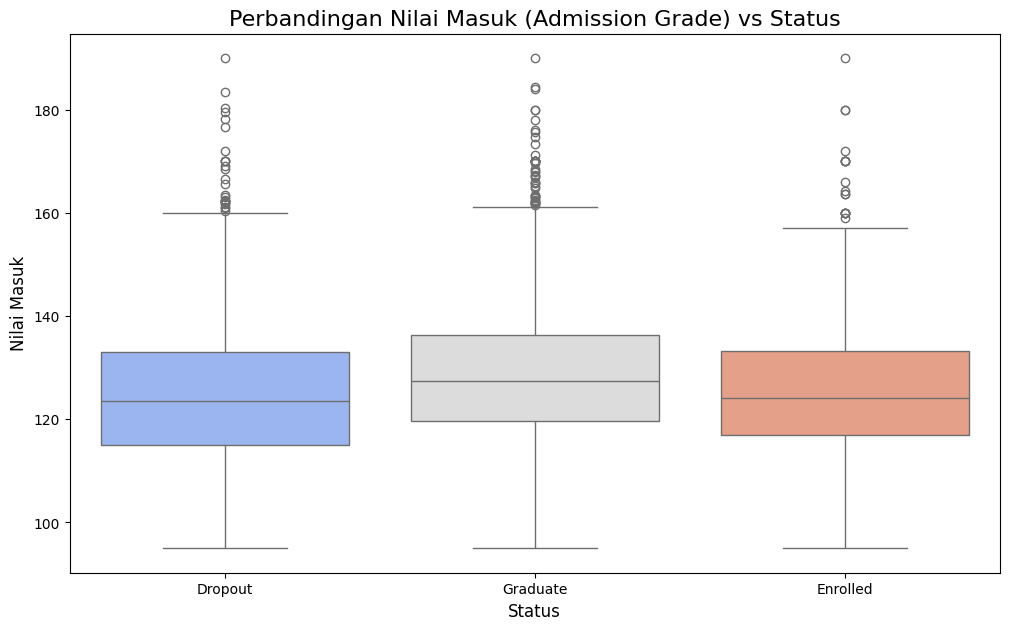

Plot ini membantu melihat apakah ada perbedaan nilai masuk yang signifikan antara ketiga status.

[ Hubungan: Gender vs Status ]


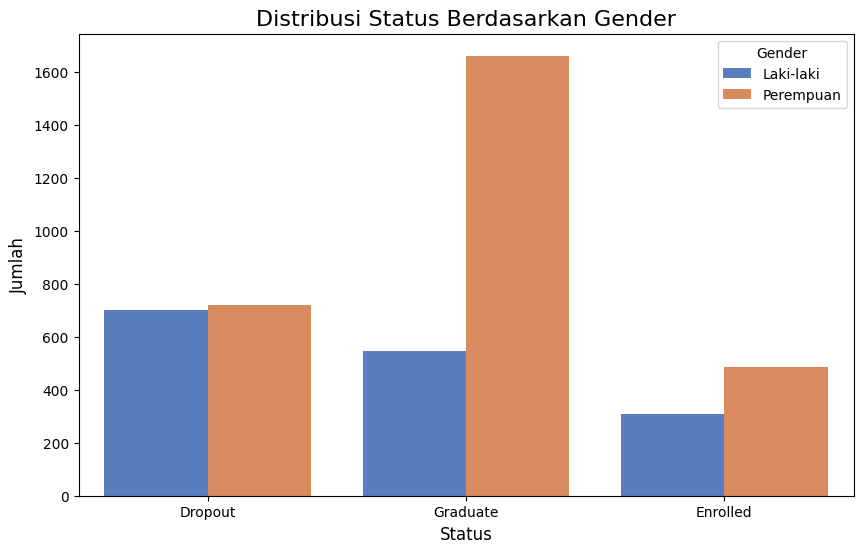

Plot ini menunjukkan proporsi laki-laki/perempuan untuk setiap status.

[ Hubungan: Mata Kuliah Lulus Semester 1 vs Status ]


/tmp/ipython-input-4181862503.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y='Curricular_units_1st_sem_approved', data=df, palette='Set2')


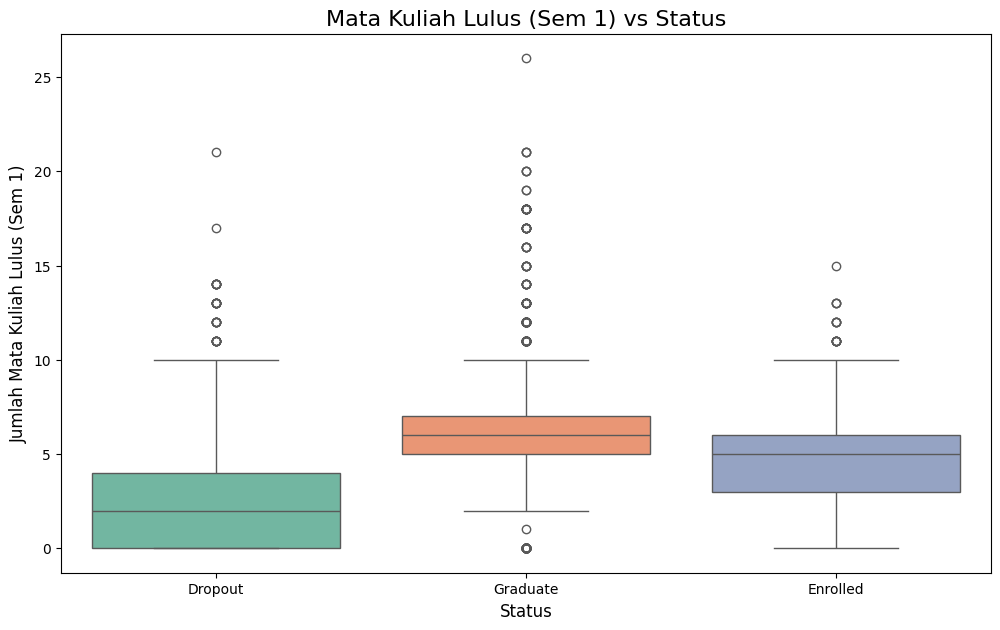

Fitur ini terlihat sangat prediktif. Rata-rata 'Dropout' memiliki jumlah matkul lulus yang jauh lebih rendah.


In [13]:
if 'df' in locals():
    print("6. ANALISIS BIVARIAT (FITUR vs TARGET)")

    # --- Contoh 1: Admission_grade vs Status ---
    print("\n[ Hubungan: Admission_grade vs Status ]")
    plt.figure(figsize=(12, 7))
    sns.boxplot(x=target_col, y='Admission_grade', data=df, palette='coolwarm')
    plt.title('Perbandingan Nilai Masuk (Admission Grade) vs Status', fontsize=16)
    plt.xlabel('Status', fontsize=12)
    plt.ylabel('Nilai Masuk', fontsize=12)
    plt.show()

    # --- Contoh 2: Gender vs Status ---
    print("\n[ Hubungan: Gender vs Status ]")
    plt.figure(figsize=(10, 6))
    sns.countplot(x=target_col, hue='Gender_label', data=df_plot, palette='muted')
    plt.title('Distribusi Status Berdasarkan Gender', fontsize=16)
    plt.xlabel('Status', fontsize=12)
    plt.ylabel('Jumlah', fontsize=12)
    plt.legend(title='Gender')
    plt.show()

    # --- Contoh 3: Curricular_units_1st_sem_approved vs Status ---
    print("\n[ Hubungan: Mata Kuliah Lulus Semester 1 vs Status ]")
    plt.figure(figsize=(12, 7))
    sns.boxplot(x=target_col, y='Curricular_units_1st_sem_approved', data=df, palette='Set2')
    plt.title('Mata Kuliah Lulus (Sem 1) vs Status', fontsize=16)
    plt.xlabel('Status', fontsize=12)
    plt.ylabel('Jumlah Mata Kuliah Lulus (Sem 1)', fontsize=12)
    plt.show()
    print("Fitur ini terlihat sangat prediktif. Rata-rata 'Dropout' memiliki jumlah matkul lulus yang jauh lebih rendah.")

**Perbandingan Nilai Masuk (Admission Grade) vs Status**

1. **Median Nilai Masuk**: Terdapat perbedaan yang jelas pada median nilai masuk antar status.

   * Mahasiswa dengan status "Graduate" (Lulus) cenderung memiliki median nilai masuk yang paling tinggi dibandingkan dua kelompok lainnya. Garis tengah pada kotak "Graduate" berada pada posisi paling atas.

   * Mahasiswa yang saat ini "Enrolled" (Terdaftar) memiliki median nilai masuk yang sedikit lebih rendah daripada yang lulus.

   * Mahasiswa dengan status "Dropout" (Keluar) menunjukkan median nilai masuk yang paling rendah di antara ketiganya.

2. **Sebaran Nilai**:
   * Sebaran nilai untuk 50% mahasiswa di tengah (ukuran kotak) tampak relatif serupa untuk ketiga kategori, namun posisi vertikal dari kotak-kotak tersebut berbeda secara signifikan.

   * Ini mengindikasikan bahwa meskipun rentang nilai di antara mahasiswa pada setiap kelompok tidak jauh berbeda, secara umum, mahasiswa yang lulus masuk dengan nilai yang lebih tinggi.

3. **Outlier (Pencilan)**:
Ketiga kategori menunjukkan adanya outlier di sisi atas, yang berarti ada mahasiswa dengan nilai masuk yang sangat tinggi di setiap kelompok status, termasuk yang akhirnya dropout.

**Kesimpulan Utama**: Grafik ini secara kuat menyiratkan adanya hubungan antara nilai masuk dengan status kelulusan mahasiswa. Rata-rata, mahasiswa yang berhasil lulus memiliki nilai masuk yang lebih tinggi daripada mereka yang masih terdaftar, dan terutama lebih tinggi daripada mereka yang memutuskan untuk keluar (dropout).

**Grafik Distribusi Status Berdasarkan Gender**

1. **Status Graduate (Lulus)**: Perbedaan paling signifikan terlihat pada kategori ini. Jumlah mahasiswa perempuan yang lulus (sekitar 1.650) jauh lebih banyak dibandingkan dengan jumlah mahasiswa laki-laki yang lulus (sekitar 550). Ini menunjukkan bahwa dalam dataset ini, perempuan memiliki tingkat kelulusan yang jauh lebih tinggi.

2. **Status Dropout (Keluar)**: Pada kategori ini, jumlah mahasiswa laki-laki dan perempuan yang keluar (dropout) hampir seimbang, dengan jumlah masing-masing berkisar di angka 700.

3. **Status Enrolled (Terdaftar)**: Serupa dengan tren kelulusan, jumlah mahasiswa perempuan yang masih aktif terdaftar (sekitar 500) lebih banyak dibandingkan mahasiswa laki-laki (sekitar 300).

**Kesimpulan Utama:**
Grafik ini secara jelas menunjukkan bahwa populasi mahasiswa dalam dataset ini didominasi oleh perempuan. Selain itu, yang paling menonjol adalah tingkat kelulusan di kalangan mahasiswa perempuan secara signifikan melampaui mahasiswa laki-laki. Di sisi lain, tingkat dropout relatif setara antara kedua gender.

**Grafik Mata Kuliah Lulus (Sem 1) vs Statu**

Wawasan penting :

1. **Kinerja Mahasiswa yang Lulus (Graduate)**:

   * Kelompok ini memiliki median jumlah mata kuliah lulus yang paling tinggi (sekitar 6 mata kuliah). Ini berarti setengah dari mahasiswa yang akhirnya lulus, berhasil menyelesaikan 6 mata kuliah atau lebih di semester pertama mereka.

   * Distribusi nilainya (kotaknya) juga berada pada posisi paling atas, menunjukkan kinerja yang secara konsisten lebih baik di awal masa studi.

2. **Kinerja Mahasiswa yang Keluar (Dropout)**:

   * Kelompok ini menunjukkan median yang paling rendah (sekitar 2 mata kuliah). Bahkan, kuartil bawahnya berada di angka 0, yang menandakan bahwa setidaknya 25% dari mahasiswa yang dropout tidak meluluskan satu mata kuliah pun di semester pertama.

   * Secara umum, 75% dari mahasiswa di kelompok ini hanya meluluskan 4 mata kuliah atau kurang di semester awal.

3. **Kinerja Mahasiswa yang Masih Terdaftar (Enrolled)**:

   * Kelompok ini berada di posisi tengah, dengan median sekitar 5 mata kuliah. Kinerjanya lebih baik daripada kelompok dropout, namun tidak setinggi kelompok yang sudah lulus.

**Kesimpulan Utama**:
Grafik ini dengan sangat jelas menunjukkan bahwa kinerja akademik di semester pertama merupakan indikator kuat terhadap status akhir mahasiswa. Mahasiswa yang berhasil meluluskan lebih banyak mata kuliah di awal perkuliahan memiliki kecenderungan yang jauh lebih besar untuk lulus, sementara mereka yang kesulitan dan hanya meluluskan sedikit mata kuliah memiliki risiko tinggi untuk dropout.

7. HEATMAP KORELASI (ANTAR FITUR NUMERIK)


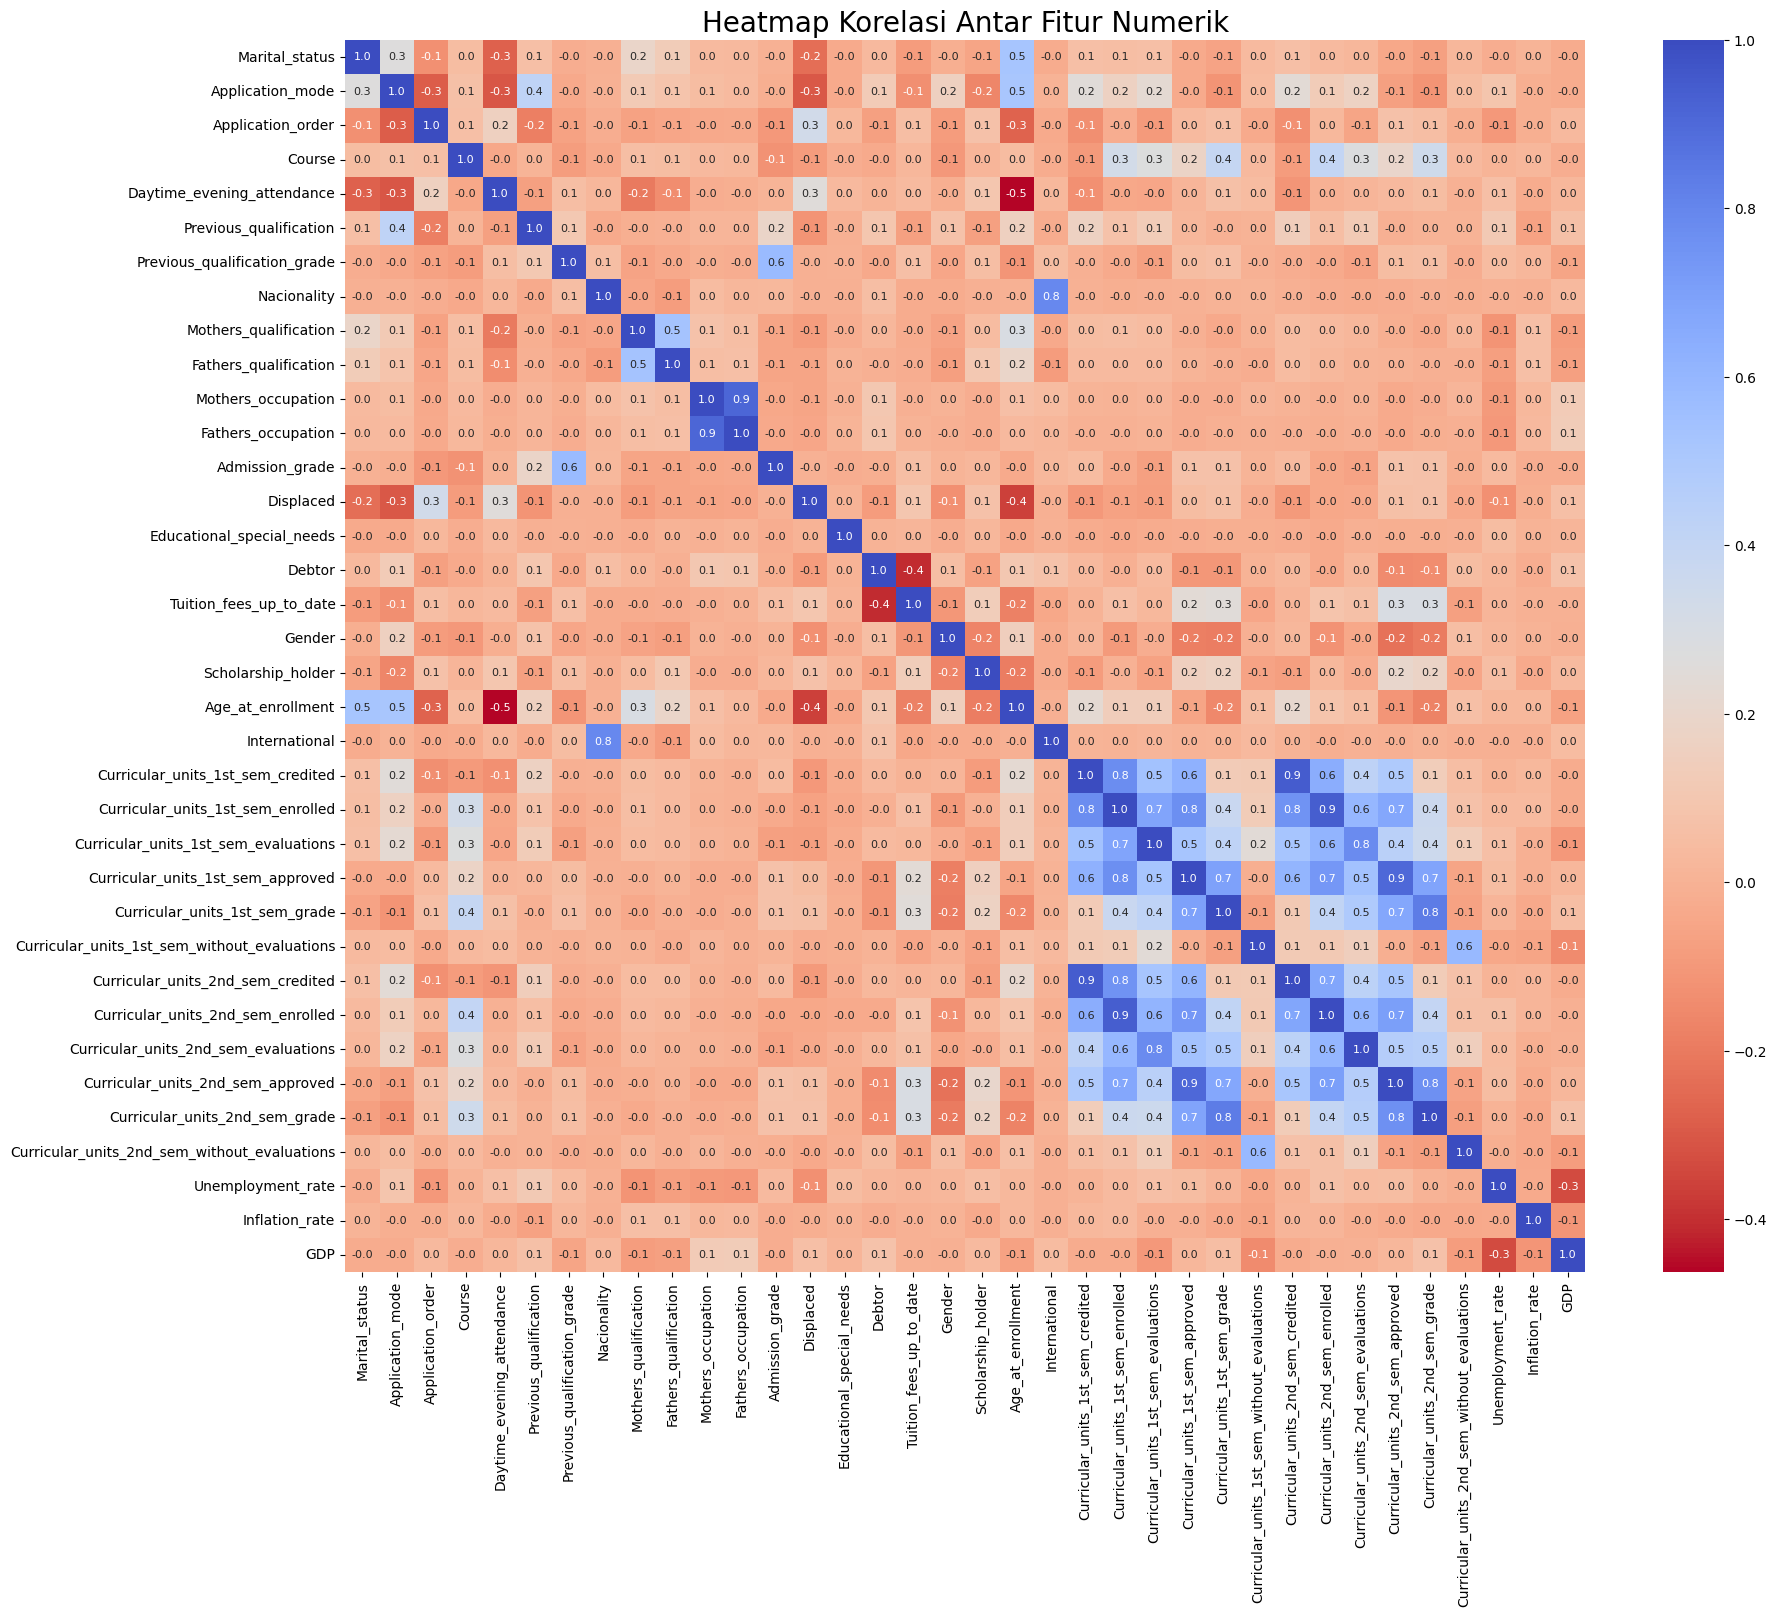

Heatmap ini berguna untuk:
1. Melihat fitur mana yang berkorelasi kuat satu sama lain (potensi multikolinearitas).
   Contoh: 'Curricular_units_1st_sem_approved' dan 'Curricular_units_1st_sem_grade' memiliki korelasi tinggi.
2. (Setelah encoding) Melihat fitur mana yang berkorelasi kuat dengan variabel target.


In [14]:
if 'df' in locals():
    print("7. HEATMAP KORELASI (ANTAR FITUR NUMERIK)")

    # Menghitung korelasi
    corr_matrix = df.corr(numeric_only=True)

    # Membuat heatmap
    plt.figure(figsize=(20, 16))
    sns.heatmap(corr_matrix, annot=True, fmt='.1f', cmap='coolwarm_r', annot_kws={"size": 8})
    plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=20)
    plt.show()

1. **Korelasi Terkuat pada Kinerja Akademik**:

   * Blok berwarna biru tua yang paling menonjol berada di antara variabel-variabel yang terkait dengan unit kurikuler (mata kuliah). Ini menunjukkan adanya korelasi positif yang sangat kuat antara kinerja mahasiswa di semester pertama dan semester kedua.

   * Sebagai contoh, jumlah mata kuliah yang dilulusi (approved) di semester pertama sangat berkorelasi dengan jumlah mata kuliah yang dilulusi di semester kedua.

   * **Kesimpulan**: Kinerja akademik mahasiswa di awal masa studi (semester 1) adalah prediktor yang sangat baik untuk kinerja mereka di semester berikutnya.

2. **Hubungan Latar Belakang Keluarga**:

   * Terdapat korelasi positif yang cukup kuat antara kualifikasi pendidikan ibu (Mothers_qualification) dan ayah (Fathers_qualification). Hal ini wajar, karena pasangan seringkali memiliki latar belakang pendidikan yang serupa.

   * Hal yang sama juga berlaku untuk pekerjaan ibu (Mothers_occupation) dan ayah (Fathers_occupation), meskipun korelasinya sedikit lebih lemah.

3. **Hubungan Status Finansial dan Akademik**:

   * Variabel Tuition_fees_up_to_date (biaya kuliah lunas) memiliki korelasi positif dengan Scholarship_holder (penerima beasiswa). Ini menunjukkan bahwa mahasiswa penerima beasiswa cenderung lebih taat dalam pembayaran.

   * Selain itu, status pembayaran biaya kuliah juga memiliki korelasi positif (meskipun tidak sangat kuat) dengan jumlah mata kuliah yang dilulusi. Ini bisa mengindikasikan bahwa stabilitas finansial dapat berdampak pada kinerja akademik.

   * Sebaliknya, status Debtor (memiliki utang) memiliki korelasi negatif dengan status pembayaran dan status beasiswa.

4. **Korelasi Lain yang Logis**:

   * Age_at_enrollment (usia saat mendaftar) memiliki korelasi positif dengan Previous_qualification (kualifikasi sebelumnya). Mahasiswa yang lebih tua saat mendaftar cenderung memiliki jenjang pendidikan sebelumnya yang lebih tinggi.

**Secara keseluruhan**, temuan paling signifikan dari heatmap ini adalah pentingnya kinerja awal dalam memprediksi keberhasilan akademik jangka panjang seorang mahasiswa.

# Data Preprocessing

In [15]:
#seleksi fitur dan penyaringan data untuk menghasilkan dataset yang bersih dan terfokus pada mahasiswa dengan status kelulusan yang sudah final (lulus atau putus studi)
used_cols = [
    'Application_mode', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Status'
]

clean_df = decoded_df[used_cols]
clean_df = clean_df[clean_df['Status'] != 'Enrolled']

In [16]:
def scaling(features,df):
    df = df.copy()
    for feature in features:
        scaler = MinMaxScaler()
        X = np.asanyarray(df[[feature]])
        X = X.reshape(-1,1)
        scaler.fit(X)
        df['{}'.format(feature)] = scaler.transform(X)
        joblib.dump(scaler, 'scaler_{}.joblib'.format(feature))
    return df

def encoding(features,df):
    df = df.copy()
    for feature in features:
        encoder = LabelEncoder()
        df['{}'.format(feature)] = encoder.fit_transform(df[feature])
        joblib.dump(encoder, 'encoder_{}.joblib'.format(feature))
    return df

**Fungsi scaling(features, df)**
Fungsi ini bertujuan untuk melakukan normalisasi pada fitur-fitur numerik yang spesifik dalam sebuah DataFrame. Dengan menggunakan MinMaxScaler, setiap fitur yang diinputkan akan diskalakan nilainya ke dalam rentang antara 0 dan 1. Objek scaler yang telah dilatih untuk setiap fitur kemudian disimpan ke dalam sebuah file .joblib agar dapat digunakan kembali pada data baru, sehingga memastikan konsistensi dalam proses transformasi.

**Fungsi encoding(features, df)**
Fungsi ini digunakan untuk mengubah data kategorikal menjadi representasi numerik. Dengan memanfaatkan LabelEncoder, setiap kategori unik dalam fitur yang ditentukan akan diubah menjadi sebuah nilai integer. Sama seperti fungsi scaling, objek encoder yang telah dilatih juga disimpan ke dalam file .joblib untuk setiap fitur, yang memungkinkan transformasi yang konsisten pada data di masa mendatang.

In [17]:
numerical_columns = clean_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_columns = clean_df.select_dtypes(include=['object']).drop(columns=['Status']).columns.tolist()

identifikasi dan memisahkan kolom-kolom dalam DataFrame menjadi dua daftar: numerical_columns untuk data numerik dan categorical_columns untuk data kategorikal (dengan mengecualikan kolom target 'Status')

In [18]:
new_clean_df=scaling(numerical_columns,clean_df)
new_clean_df=encoding(categorical_columns,new_clean_df)

fungsi scaling diterapkan pada semua kolom numerik untuk melakukan normalisasi, dan fungsi encoding diterapkan pada semua kolom kategorikal untuk mengubahnya menjadi format numerik. Hasil akhirnya adalah new_clean_df, sebuah DataFrame yang sepenuhnya telah ditransformasi dan siap untuk digunakan dalam pelatihan model machine

In [19]:
#Pisahkan fitur untuk X dan target y
X = new_clean_df.drop(columns=['Status'])
y = new_clean_df['Status']

In [20]:
#Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(2904, 10)
(726, 10)


Splitting dilakukan di awal sebelum balancing data untuk menghindari kebocoran data yang mengakibatkan bias pada saat evaluasi

In [21]:
#Balancing data mengguakan oversampling
oversampler = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

In [22]:
#Encoding variabel
encoder = LabelEncoder()
encoder.fit(y_train_resampled)
new_y_train = encoder.transform(y_train_resampled)
joblib.dump(encoder, 'status_encoder.joblib')

new_y_test = encoder.transform(y_test)

# Modeling

In [23]:
#Bangun model menggunakan Random Forest Classifier dan menerapkan hyperparameter tuning untuk mendapatkan parameter terbaik
rdf_model = RandomForestClassifier(random_state=123)

param_grid = {
    'n_estimators': [200, 500],
    'max_features': ['sqrt', 'log2'],
    'max_depth' : [6, 7, 8],
    'criterion' :['gini', 'entropy']
}

CV_rdf = GridSearchCV(estimator=rdf_model, param_grid=param_grid, cv=5, n_jobs=-1)
CV_rdf.fit(X_train_resampled, new_y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=123),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [6, 7, 8],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [200, 500]})

In [24]:
#Hasil parameter terbaik
print("best parameters: ", CV_rdf.best_params_)

best parameters:  {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 200}


In [25]:
#Training model dan simpan modelnya
rdf_model = RandomForestClassifier(
    random_state=123,
    max_depth=8,
    n_estimators=500,
    max_features='log2',
    criterion='gini',
    n_jobs=-1
)
rdf_model.fit(X_train_resampled, new_y_train)
joblib.dump(rdf_model, "rdf_model.joblib")

['rdf_model.joblib']

# Evaluasi

Akurasi model Random Forest: 0.8884297520661157
Classification Report model Random Forest:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       277
           1       0.89      0.93      0.91       449

    accuracy                           0.89       726
   macro avg       0.89      0.88      0.88       726
weighted avg       0.89      0.89      0.89       726



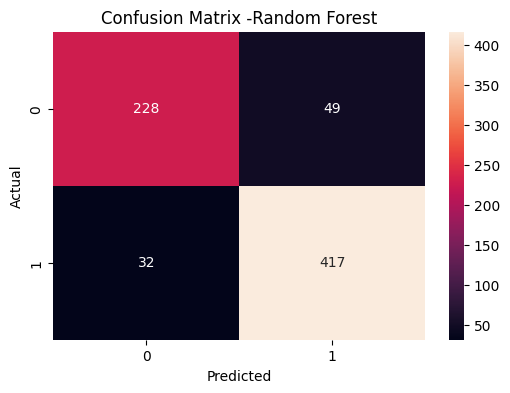

In [26]:
#evaluasi menggunakan classification report dan confusion matrik pada data test
y_pred = rdf_model.predict(X_test)

label_encoder = LabelEncoder()
label_encoder.fit(y_test)
y_test_numeric = label_encoder.transform(y_test)

accuracy = accuracy_score(y_test_numeric, y_pred)
print(f"Akurasi model Random Forest: {accuracy}")

print(f"Classification Report model Random Forest:")
print(classification_report(y_test_numeric, y_pred))

cm = confusion_matrix(y_test_numeric, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title(f"Confusion Matrix -Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Akurasi: 92.24%

Classification Report:
              precision    recall  f1-score   support

Graduate (0)       0.96      0.88      0.92      1760
 Dropout (1)       0.89      0.96      0.93      1760

    accuracy                           0.92      3520
   macro avg       0.93      0.92      0.92      3520
weighted avg       0.93      0.92      0.92      3520



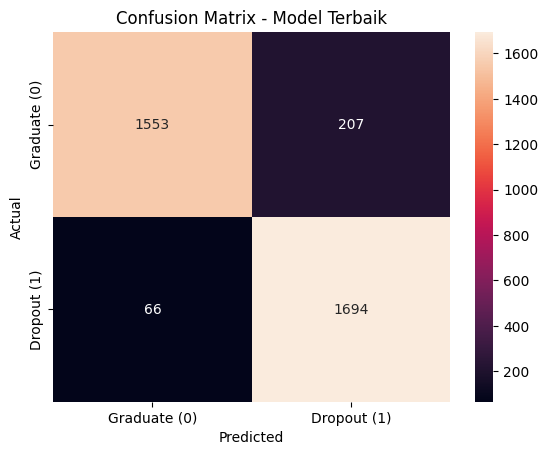

In [27]:
#evaluasi menggunakan classification report dan confusion matrik pada data train
#buat evaluasi akurasi untuk data train
y_pred_train = rdf_model.predict(X_train_resampled)
print(f"Akurasi: {accuracy_score(new_y_train, y_pred_train) * 100:.2f}%")

#buat Classification Report untuk data train
print("\nClassification Report:")
print(classification_report(new_y_train, y_pred_train, target_names=['Graduate (0)', 'Dropout (1)']))

#buat confusion matrix untuk data train
cm_train = confusion_matrix(new_y_train, y_pred_train)

sns.heatmap(cm_train, annot=True, fmt="d",
            xticklabels=['Graduate (0)', 'Dropout (1)'],
            yticklabels=['Graduate (0)', 'Dropout (1)'])
plt.title(f"Confusion Matrix - Model Terbaik")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
#export model ke format joblib
joblib.dump(rdf_model, 'rdf_model.joblib')

['rdf_model.joblib']

In [29]:
!pip install sqlalchemy

In [30]:
!pip freeze > requirements.txt

# Fitur Penting

In [32]:
# buat fitur importance
# Mengambil feature importance dari model Random Forest
feature_importances = rdf_model.feature_importances_

In [33]:
# Membuat DataFrame untuk feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

/tmp/ipython-input-613845133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette="viridis")


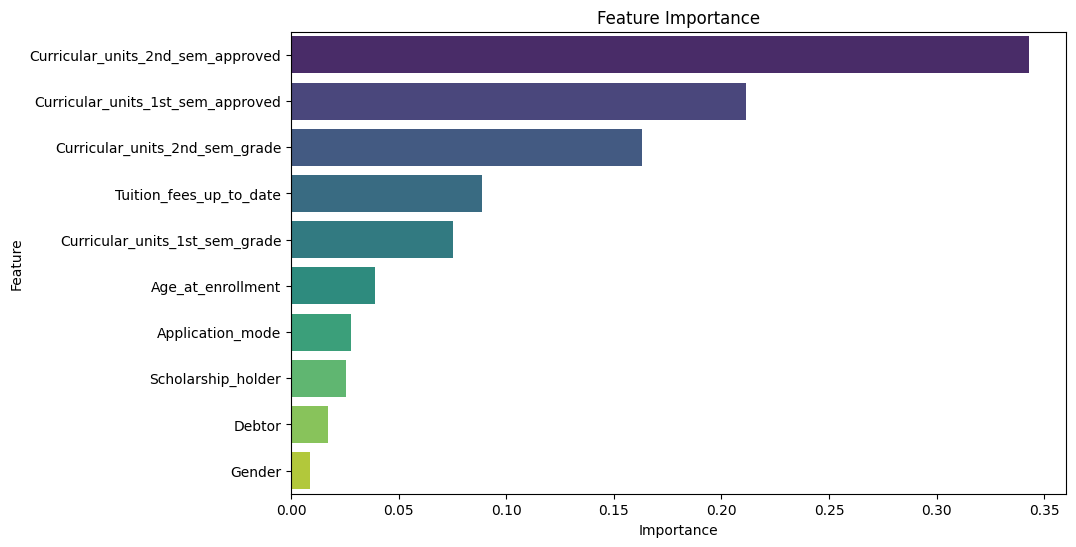

In [34]:
# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette="viridis")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [36]:
importance_df
importance_df.to_csv("importance_features.csv", index=False)